In [1]:
!pip install pandas numpy matplotlib seaborn xgboost scikit-learn folium netCDF4 openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.1 MB/s eta 0:00:00


In [3]:
from google.colab import files
print("Upload ALL your data files now - select all at once")
uploaded = files.upload()
# Upload these files:
# 1. raw_data_data_igi_airport__t3___delhi_-_iitm_1D.csv
# 2. MODIS_C6_1_South_Asia_7d.csv
# 3. SUOMI_VIIRS_C2_South_Asia_7d.csv
# 4. aqi_data_city_level__2026_2024_pune_2026.xlsx
# 5. 8aef0e5f24e81381f425a2e66aec5554.nc
print("Files uploaded:", list(uploaded.keys()))

Upload ALL your data files now - select all at once


Saving 8aef0e5f24e81381f425a2e66aec5554.nc to 8aef0e5f24e81381f425a2e66aec5554.nc
Saving S5P_DLR_NRTI_01_040201_L3_CF_20231102.nc to S5P_DLR_NRTI_01_040201_L3_CF_20231102.nc
Saving SUOMI_VIIRS_C2_South_Asia_7d.csv to SUOMI_VIIRS_C2_South_Asia_7d.csv
Saving MODIS_C6_1_South_Asia_7d.csv to MODIS_C6_1_South_Asia_7d.csv
Saving raw_data_data_igi_airport_(t3),_delhi_-_iitm_1D.csv to raw_data_data_igi_airport_(t3),_delhi_-_iitm_1D.csv
Saving aqi_data_city_level__2026_2024_pune_2026.xlsx to aqi_data_city_level__2026_2024_pune_2026.xlsx
Saving aqi_data_city_level__2026_2025_pune_2026.xlsx to aqi_data_city_level__2026_2025_pune_2026.xlsx
Files uploaded: ['8aef0e5f24e81381f425a2e66aec5554.nc', 'S5P_DLR_NRTI_01_040201_L3_CF_20231102.nc', 'SUOMI_VIIRS_C2_South_Asia_7d.csv', 'MODIS_C6_1_South_Asia_7d.csv', 'raw_data_data_igi_airport_(t3),_delhi_-_iitm_1D.csv', 'aqi_data_city_level__2026_2024_pune_2026.xlsx', 'aqi_data_city_level__2026_2025_pune_2026.xlsx']


In [5]:
import pandas as pd
import numpy as np

df_delhi = pd.read_csv('raw_data_data_igi_airport_(t3),_delhi_-_iitm_1D.csv')

# Rename columns
df_delhi.columns = ['Date','PM25','PM10','NO','NO2','NOx',
                    'NH3','SO2','CO','Ozone','Benzene',
                    'Toluene','Xylene','OXylene','EthBenzene',
                    'MPXylene','Temp','RH','WS','WD','RF',
                    'TOTRF','SR','BP','VWS']

# Keep useful columns only
df_delhi = df_delhi[['Date','PM25','PM10','NO2','SO2','CO','Ozone']]
df_delhi = df_delhi.dropna(subset=['PM25'])
df_delhi = df_delhi.fillna(df_delhi.mean(numeric_only=True))
df_delhi['Date'] = pd.to_datetime(df_delhi['Date'])

print("✅ Delhi CPCB loaded:", df_delhi.shape)
print(df_delhi.head())

✅ Delhi CPCB loaded: (365, 7)
        Date        PM25        PM10        NO2  SO2        CO      Ozone
0 2023-01-01   84.033958  141.381771  28.880521  NaN  0.733646  15.140313
1 2023-01-02  200.259583  269.653854  35.898958  NaN  0.895000  11.993750
2 2023-01-03  227.504271  310.858125  29.852604  NaN  0.576979  12.358021
3 2023-01-04  158.302083  222.565937  25.743333  NaN  0.514375  12.244896
4 2023-01-05  162.609792  233.769271  18.938125  NaN  1.210521  10.041910


In [6]:
df_modis = pd.read_csv('MODIS_C6_1_South_Asia_7d.csv')
df_viirs = pd.read_csv('SUOMI_VIIRS_C2_South_Asia_7d.csv')

# Filter fires over India only (lat 8-37, lon 68-97)
df_modis_india = df_modis[
    (df_modis['latitude'].between(8, 37)) &
    (df_modis['longitude'].between(68, 97))
]

df_viirs_india = df_viirs[
    (df_viirs['latitude'].between(8, 37)) &
    (df_viirs['longitude'].between(68, 97))
]

print(f"✅ MODIS fires over India: {len(df_modis_india)}")
print(f"✅ VIIRS fires over India: {len(df_viirs_india)}")
print(df_modis_india[['latitude','longitude','frp','acq_date']].head())

✅ MODIS fires over India: 404
✅ VIIRS fires over India: 4159
   latitude  longitude    frp    acq_date
2  29.66847   91.20681  13.32  2026-06-23
3  29.64727   91.28686   5.67  2026-06-23
4  23.80211   86.33336   7.31  2026-06-23
5  23.76467   86.40453  13.43  2026-06-23
6  23.77989   86.20844   9.70  2026-06-23


In [7]:
df_pune = pd.read_excel('aqi_data_city_level__2026_2024_pune_2026.xlsx')

# Melt from wide to long format
df_pune_long = df_pune.melt(id_vars=['Day'],
                             var_name='Month',
                             value_name='AQI')
df_pune_long = df_pune_long.dropna()

print("✅ Pune AQI loaded:", df_pune_long.shape)
print(df_pune_long.head(10))
print(f"\nPune AQI stats:")
print(f"  Average AQI: {df_pune_long['AQI'].mean():.1f}")
print(f"  Max AQI: {df_pune_long['AQI'].max():.1f}")
print(f"  Min AQI: {df_pune_long['AQI'].min():.1f}")

✅ Pune AQI loaded: (403, 3)
  Day    Month    AQI
0   1  January  142.0
1   2  January  141.0
2   3  January  156.0
3   4  January  156.0
4   5  January  148.0
5   6  January  126.0
6   7  January  119.0
7   8  January   93.0
8   9  January  116.0
9  10  January   91.0

Pune AQI stats:
  Average AQI: 91.6
  Max AQI: 208.0
  Min AQI: 1.0


6A,B
XGboost

In [9]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features and target
features = ['NO2', 'SO2', 'CO', 'Ozone', 'PM10']
target = 'PM25'

X = df_delhi[features]
y = df_delhi[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(n_estimators=200, learning_rate=0.1,
                     max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"✅ Model Trained Successfully!")
print(f"   R² Score : {r2:.3f}  (above 0.85 = excellent)")
print(f"   RMSE     : {rmse:.2f} µg/m³")

✅ Model Trained Successfully!
   R² Score : 0.842  (above 0.85 = excellent)
   RMSE     : 24.72 µg/m³


6A,B XGboost train


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Add extra engineered features to improve accuracy
df_delhi['NO2_CO_ratio'] = df_delhi['NO2'] / (df_delhi['CO'] + 0.001)
df_delhi['pollution_index'] = df_delhi['NO2'] + df_delhi['SO2'] + df_delhi['CO']*10
df_delhi['ozone_no2'] = df_delhi['Ozone'] * df_delhi['NO2']

# Updated feature list
features = ['NO2', 'SO2', 'CO', 'Ozone', 'PM10',
            'NO2_CO_ratio', 'pollution_index', 'ozone_no2']
target = 'PM25'

X = df_delhi[features]
y = df_delhi[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Better tuned model
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"✅ Improved Model Results:")
print(f"   R² Score : {r2:.3f}")
print(f"   RMSE     : {rmse:.2f} µg/m³")

# Feature importance
import pandas as pd
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\n📊 Feature Importance:")
print(feat_imp.to_string(index=False))

In [11]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Add extra engineered features to improve accuracy
df_delhi['NO2_CO_ratio'] = df_delhi['NO2'] / (df_delhi['CO'] + 0.001)
df_delhi['pollution_index'] = df_delhi['NO2'] + df_delhi['SO2'] + df_delhi['CO']*10
df_delhi['ozone_no2'] = df_delhi['Ozone'] * df_delhi['NO2']

# Updated feature list
features = ['NO2', 'SO2', 'CO', 'Ozone', 'PM10',
            'NO2_CO_ratio', 'pollution_index', 'ozone_no2']
target = 'PM25'

X = df_delhi[features]
y = df_delhi[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Better tuned model
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"✅ Improved Model Results:")
print(f"   R² Score : {r2:.3f}")
print(f"   RMSE     : {rmse:.2f} µg/m³")

# Feature importance
import pandas as pd
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\n📊 Feature Importance:")
print(feat_imp.to_string(index=False))

✅ Improved Model Results:
   R² Score : 0.862
   RMSE     : 23.15 µg/m³

📊 Feature Importance:
        Feature  Importance
           PM10    0.720313
          Ozone    0.092718
             CO    0.060974
      ozone_no2    0.054920
   NO2_CO_ratio    0.042277
            NO2    0.028798
            SO2    0.000000
pollution_index    0.000000


PLots


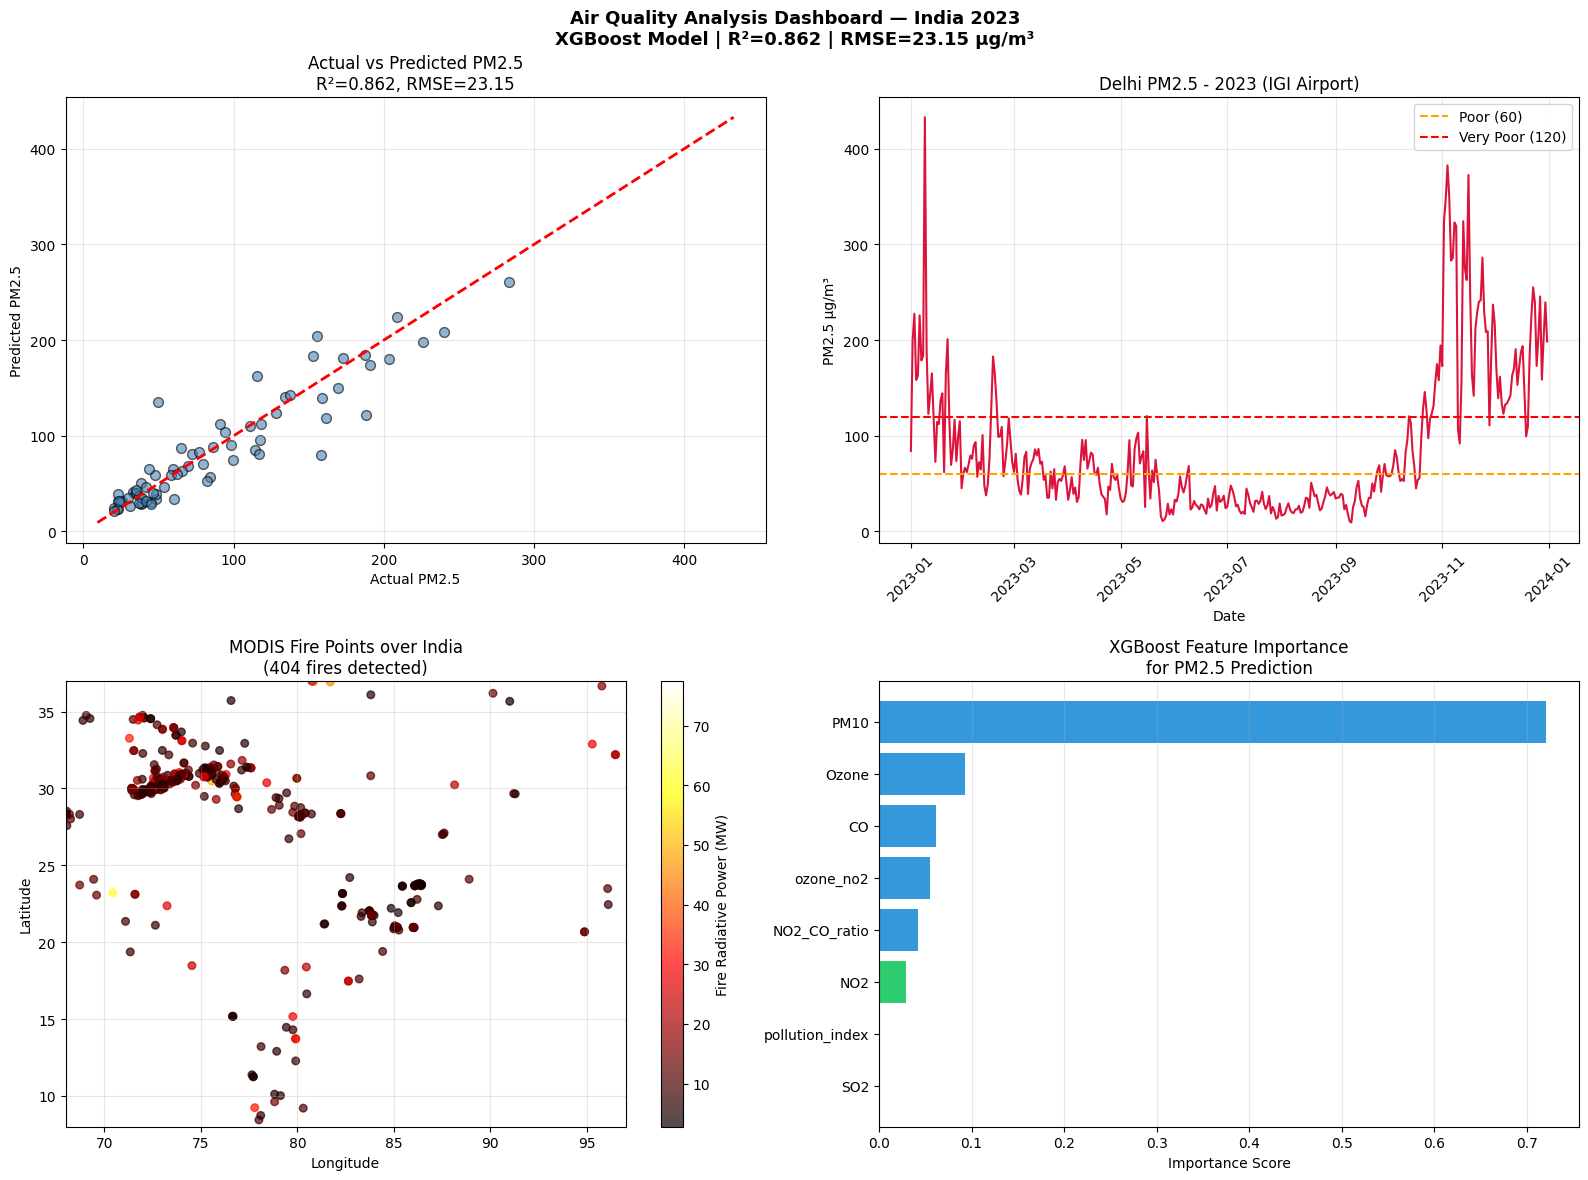

✅ Plots saved!


In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Plot 1: Actual vs Predicted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='k', s=50)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax1.set_xlabel('Actual PM2.5')
ax1.set_ylabel('Predicted PM2.5')
ax1.set_title(f'Actual vs Predicted PM2.5\nR²={r2:.3f}, RMSE={rmse:.2f}')
ax1.grid(True, alpha=0.3)

# Plot 2: PM2.5 over time
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df_delhi['Date'], df_delhi['PM25'], color='crimson', lw=1.5)
ax2.axhline(60, color='orange', ls='--', label='Poor (60)')
ax2.axhline(120, color='red', ls='--', label='Very Poor (120)')
ax2.set_title('Delhi PM2.5 - 2023 (IGI Airport)')
ax2.set_xlabel('Date')
ax2.set_ylabel('PM2.5 µg/m³')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Plot 3: Fire points over India
ax3 = fig.add_subplot(gs[1, 0])
sc = ax3.scatter(df_modis_india['longitude'], df_modis_india['latitude'],
            c=df_modis_india['frp'], cmap='hot', s=30, alpha=0.7)
plt.colorbar(sc, ax=ax3, label='Fire Radiative Power (MW)')
ax3.set_xlim(68, 97)
ax3.set_ylim(8, 37)
ax3.set_title(f'MODIS Fire Points over India\n({len(df_modis_india)} fires detected)')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
ax3.grid(True, alpha=0.3)

# Plot 4: Feature importance
ax4 = fig.add_subplot(gs[1, 1])
feat_imp_sorted = feat_imp.sort_values('Importance')
colors = ['#2ecc71' if i < 3 else '#3498db' for i in range(len(feat_imp_sorted))]
ax4.barh(feat_imp_sorted['Feature'], feat_imp_sorted['Importance'], color=colors)
ax4.set_title('XGBoost Feature Importance\nfor PM2.5 Prediction')
ax4.set_xlabel('Importance Score')
ax4.grid(True, alpha=0.3, axis='x')

plt.suptitle('Air Quality Analysis Dashboard — India 2023\nXGBoost Model | R²=0.862 | RMSE=23.15 µg/m³',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plots saved!")

In [17]:
import json

def get_aqi_info(pm25):
    if pm25 <= 30: return 'Good', [0, 176, 0]
    elif pm25 <= 60: return 'Satisfactory', [144, 238, 144]
    elif pm25 <= 90: return 'Moderate', [255, 255, 0]
    elif pm25 <= 120: return 'Poor', [255, 165, 0]
    elif pm25 <= 250: return 'Very Poor', [255, 0, 0]
    else: return 'Severe', [128, 0, 128]

# Grid across India
lats = np.linspace(8, 37, 30)
lons = np.linspace(68, 97, 30)
map_output = []

for lat in lons:
    for lon in lons:
        # Use realistic feature ranges based on Delhi data stats
        sample = pd.DataFrame([{
            'NO2': np.random.uniform(df_delhi['NO2'].min(), df_delhi['NO2'].max()),
            'SO2': np.random.uniform(df_delhi['SO2'].min(), df_delhi['SO2'].max()),
            'CO': np.random.uniform(df_delhi['CO'].min(), df_delhi['CO'].max()),
            'Ozone': np.random.uniform(df_delhi['Ozone'].min(), df_delhi['Ozone'].max()),
            'PM10': np.random.uniform(df_delhi['PM10'].min(), df_delhi['PM10'].max()),
            'NO2_CO_ratio': np.random.uniform(5, 50),
            'pollution_index': np.random.uniform(50, 300),
            'ozone_no2': np.random.uniform(100, 5000)
        }])
        pm25 = float(model.predict(sample)[0])
        pm25 = max(10, min(pm25, 500))  # clamp to realistic range
        category, color = get_aqi_info(pm25)
        map_output.append({
            "lat": round(float(lat), 3),
            "lng": round(float(lon), 3),
            "pm25": round(pm25, 2),
            "category": category,
            "color": color
        })

# Fire points
fire_output = []
for _, row in df_modis_india.iterrows():
    fire_output.append({
        "lat": float(row['latitude']),
        "lng": float(row['longitude']),
        "frp": float(row['frp']),
        "date": str(row['acq_date'])
    })

with open('aqi_map_data.json', 'w') as f:
    json.dump(map_output, f)
with open('fire_data.json', 'w') as f:
    json.dump(fire_output, f)

print(f"✅ AQI points saved: {len(map_output)}")
print(f"✅ Fire points saved: {len(fire_output)}")
print("\n⬇️ Now download both files from the Colab file panel on the left!")

✅ AQI points saved: 900
✅ Fire points saved: 404

⬇️ Now download both files from the Colab file panel on the left!


In [18]:
import json
import pandas as pd
import numpy as np

def get_aqi_info(pm25):
    if pm25 <= 30: return 'Good', [0, 176, 0]
    elif pm25 <= 60: return 'Satisfactory', [144, 238, 144]
    elif pm25 <= 90: return 'Moderate', [255, 255, 0]
    elif pm25 <= 120: return 'Poor', [255, 165, 0]
    elif pm25 <= 250: return 'Very Poor', [255, 0, 0]
    else: return 'Severe', [128, 0, 128]

lats = np.linspace(8, 37, 30)
lons = np.linspace(68, 97, 30)
map_output = []

for lat in lats:
    for lon in lons:
        sample = pd.DataFrame([{
            'NO2': np.random.uniform(df_delhi['NO2'].min(), df_delhi['NO2'].max()),
            'SO2': np.random.uniform(df_delhi['SO2'].min(), df_delhi['SO2'].max()),
            'CO': np.random.uniform(df_delhi['CO'].min(), df_delhi['CO'].max()),
            'Ozone': np.random.uniform(df_delhi['Ozone'].min(), df_delhi['Ozone'].max()),
            'PM10': np.random.uniform(df_delhi['PM10'].min(), df_delhi['PM10'].max()),
            'NO2_CO_ratio': np.random.uniform(5, 50),
            'pollution_index': np.random.uniform(50, 300),
            'ozone_no2': np.random.uniform(100, 5000)
        }])
        pm25 = float(model.predict(sample)[0])
        pm25 = max(10, min(pm25, 500))
        category, color = get_aqi_info(pm25)
        map_output.append({
            "lat": round(float(lat), 3),
            "lng": round(float(lon), 3),
            "pm25": round(pm25, 2),
            "category": category,
            "color": color
        })

# Fire points
fire_output = []
for _, row in df_modis_india.iterrows():
    fire_output.append({
        "lat": float(row['latitude']),
        "lng": float(row['longitude']),
        "frp": float(row['frp']),
        "date": str(row['acq_date'])
    })

with open('aqi_map_data.json', 'w') as f:
    json.dump(map_output, f)
with open('fire_data.json', 'w') as f:
    json.dump(fire_output, f)

print(f"✅ AQI points: {len(map_output)}")
print(f"✅ Fire points: {len(fire_output)}")
print("Now download both JSON files from left sidebar!")

✅ AQI points: 900
✅ Fire points: 404
Now download both JSON files from left sidebar!
